In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the master dataset
df = pd.read_csv('yield_df.csv')

# Display the first 5 rows to make sure it worked
df.head()

,Unnamed: 0,Area,Item,Year,hg/ha_yield,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,0,Albania,Maize,1990,36613,1485.0,121.0,16.37
1,1,Albania,Potatoes,1990,66667,1485.0,121.0,16.37
2,2,Albania,"Rice, paddy",1990,23333,1485.0,121.0,16.37
3,3,Albania,Sorghum,1990,12500,1485.0,121.0,16.37
4,4,Albania,Soybeans,1990,7000,1485.0,121.0,16.37


In [2]:
# 1. Drop the useless index column
df = df.drop(['Unnamed: 0'], axis=1)

# 2. Check the size of our dataset (Rows, Columns)
print(f"Dataset Shape: {df.shape}\n")

# 3. Check for any missing/null values across all columns
print("Missing Values per Column:")
print(df.isnull().sum())

# 4. Get a quick summary of the data types
print("\nData Types:")
df.info()

Dataset Shape: (28242, 7)

Missing Values per Column:
Area                             0
Item                             0
Year                             0
hg/ha_yield                      0
average_rain_fall_mm_per_year    0
pesticides_tonnes                0
avg_temp                         0
dtype: int64

Data Types:
<class 'pandas.DataFrame'>
RangeIndex: 28242 entries, 0 to 28241
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Area                           28242 non-null  str    
 1   Item                           28242 non-null  str    
 2   Year                           28242 non-null  int64  
 3   hg/ha_yield                    28242 non-null  int64  
 4   average_rain_fall_mm_per_year  28242 non-null  float64
 5   pesticides_tonnes              28242 non-null  float64
 6   avg_temp                       28242 non-null  float64
dtypes: float64(3), int64(2), str(2)
m

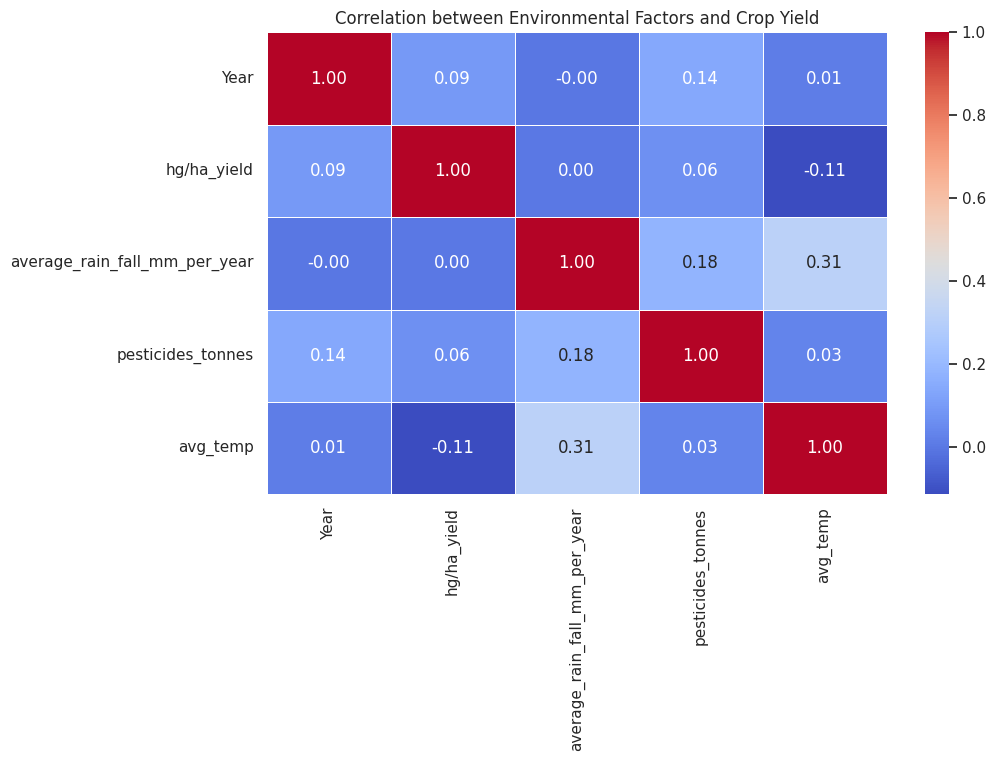

--------------------------------------------------


/tmp/ipykernel_38360/3719587905.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=crop_yield.values, y=crop_yield.index, palette='viridis')


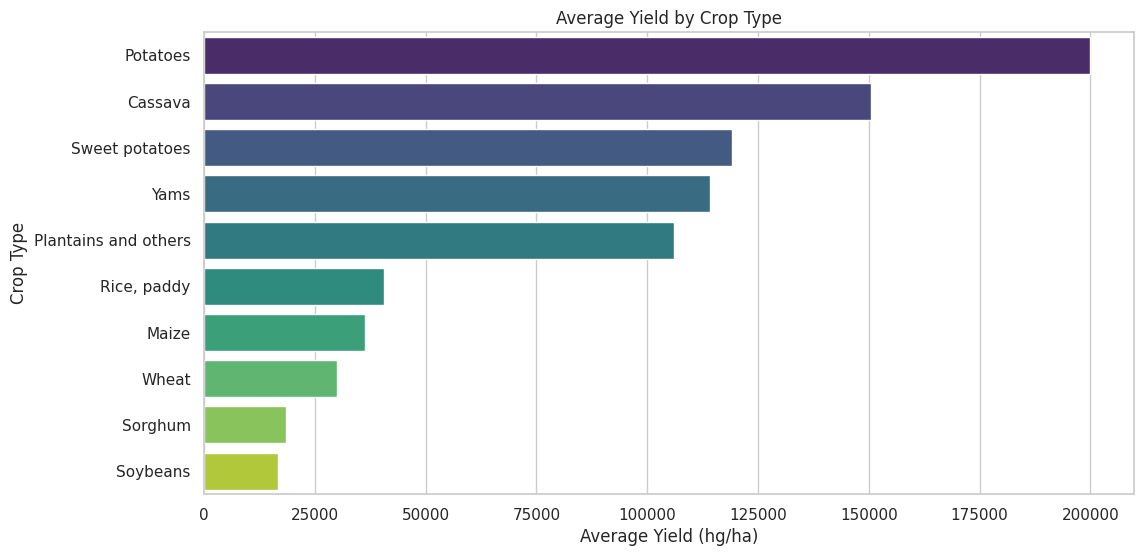

In [3]:
# Set the visual style for our graphs
sns.set_theme(style="whitegrid")

# Graph 1: Correlation Heatmap 
# This shows how strongly each number relates to the crop yield
plt.figure(figsize=(10, 6))
numeric_cols = df.select_dtypes(include=['int64', 'float64']) # Grab only the numbers
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation between Environmental Factors and Crop Yield")
plt.show()

print("-" * 50) # Just a visual divider line

# Graph 2: Top Crops by Average Yield
plt.figure(figsize=(12, 6))
crop_yield = df.groupby('Item')['hg/ha_yield'].mean().sort_values(ascending=False)
sns.barplot(x=crop_yield.values, y=crop_yield.index, palette='viridis')
plt.xlabel('Average Yield (hg/ha)')
plt.ylabel('Crop Type')
plt.title('Average Yield by Crop Type')
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

# 1. One-Hot Encoding: Convert text columns ('Area' and 'Item') into numbers (1s and 0s)
# drop_first=True prevents a math issue called the "dummy variable trap"
df_encoded = pd.get_dummies(df, columns=['Area', 'Item'], drop_first=True)

# 2. Separate the Target (what we want to predict) from the Features (the clues)
# y is the answer key. X is everything else.
y = df_encoded['hg/ha_yield']
X = df_encoded.drop('hg/ha_yield', axis=1)

# 3. Split the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data successfully prepared!")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Data successfully prepared!
Training features shape: (22593, 113)
Testing features shape: (5649, 113)


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

print("Training Linear Regression...")
# 1. Initialize and Train the Linear Regression Model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_predictions = lr_model.predict(X_test)

print("Training Random Forest (This might take 10-20 seconds!)...")
# 2. Initialize and Train the Random Forest Model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_predictions = rf_model.predict(X_test)

# 3. Evaluate the Models (Let's see how smart they got!)
print("\n--- Model Performance on the Test Set ---")

# R2 Score tells us what percentage of the variance our model explains (closer to 1.0 is better)
lr_r2 = r2_score(y_test, lr_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Linear Regression R2 Score: {lr_r2:.4f}")
print(f"Random Forest R2 Score: {rf_r2:.4f}")

Training Linear Regression...
Training Random Forest (This might take 10-20 seconds!)...

--- Model Performance on the Test Set ---
Linear Regression R2 Score: 0.7551
Random Forest R2 Score: 0.9875
